# 02 — Delivery Time Analysis

**RouteIQ — Delivery Operations Analytics**

**Business question:** How does `Delivery_Time` vary across the operational
segments RouteIQ can act on — area, category, weather, traffic, vehicle, and
weekday vs. weekend?

**Data used:** `data/cleaned/cleaned_delivery.csv` (43,648 rows), read-only.

**Analysis performed:** reuses `describe_by_segment()`
(`python/analysis/01_eda_overview.py`) and the segment-comparison functions
in `python/analysis/02_segment_comparisons.py` — no calculation is
reimplemented independently. Formal significance testing for these same
segments is deferred to `05_statistical_analysis.ipynb`; this notebook is
descriptive.


In [1]:
from _nb_theme import setup_paths, apply_theme, NAVY, TEAL, CORAL, NEUTRAL_SEQUENCE, annotate_bars, sample_size_caption
project_root = setup_paths()
apply_theme()

import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from _common import load_cleaned_data

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
df = load_cleaned_data()
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns from data/cleaned/cleaned_delivery.csv")


2026-08-17 14:25:52 | INFO     | routeiq_phase4 | Logging initialized. Log file: C:\Data Analyst Projects\RouteIQ Project\logs\phase1_pipeline_20260817_142552.log


2026-08-17 14:25:53 | INFO     | routeiq_phase4 | Loaded approved cleaned dataset: 43648 rows, 30 columns


Loaded 43,648 rows, 30 columns from data/cleaned/cleaned_delivery.csv


In [2]:
m1 = importlib.import_module("01_eda_overview")
m2 = importlib.import_module("02_segment_comparisons")


## 1. Delivery Time by Category

**Analysis performed:** `describe_by_segment(df, "Category")`, visualized as
a box plot (outliers hidden for readability — see notebook 01 for the
formal outlier analysis).


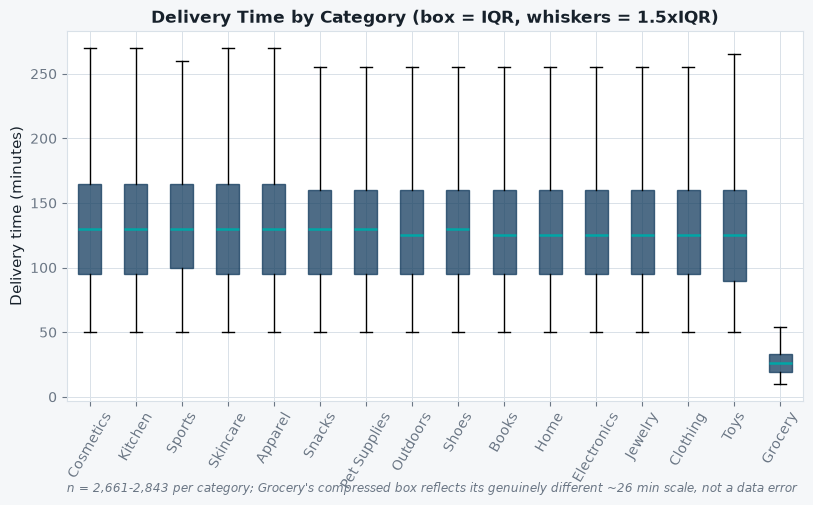

In [3]:
by_category = m1.describe_by_segment(df, "Category")
cat_order = pd.DataFrame(by_category).T.sort_values("mean", ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
data = [df.loc[df["Category"] == c, "Delivery_Time"].to_numpy() for c in cat_order]
bp = ax.boxplot(data, tick_labels=cat_order, showfliers=False, patch_artist=True)
for box in bp["boxes"]:
    box.set(facecolor=NAVY, alpha=0.75, edgecolor=NAVY)
for median_line in bp["medians"]:
    median_line.set(color=TEAL, linewidth=1.8)
ax.set_title("Delivery Time by Category (box = IQR, whiskers = 1.5xIQR)")
ax.set_ylabel("Delivery time (minutes)")
ax.tick_params(axis="x", rotation=60)
sample_size_caption(ax, "n = 2,661-2,843 per category; Grocery's compressed box reflects its genuinely different ~26 min scale, not a data error")
plt.show()


**Key observation:** `Grocery` is the clear outlier category by design
(26.54 min average) — a genuinely different, faster-fulfillment product
type, not a data error. The other 15 categories cluster tightly around
129–133 min average, with materially overlapping distributions.

**Limitation:** This shows association/distribution only — it does not
establish that category itself causes the time difference; `Grocery`'s
scale difference is a known, documented product-fulfillment property.


## 2. Delivery Time by Traffic and by Weather

**Analysis performed:** `describe_by_segment(df, "Traffic")` and
`describe_by_segment(df, "Weather")`. Formal significance/effect-size
testing for both is in notebook 05 (Tests 1–2); this section is the
descriptive picture those tests explain.


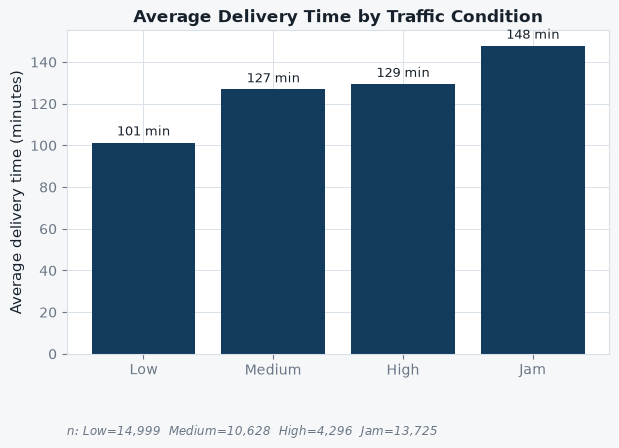

,n,mean,median,std,p90
Low,"14,999.0000",101.3500,100.0000,38.8000,145.0000
Medium,"10,628.0000",126.8400,130.0000,48.7100,190.0000
High,"4,296.0000",129.4200,135.0000,48.2700,185.0000
Jam,"13,725.0000",147.7600,150.0000,56.8100,220.0000


In [4]:
by_traffic = pd.DataFrame(m1.describe_by_segment(df, "Traffic")).T
by_traffic = by_traffic.reindex(["Low", "Medium", "High", "Jam"])

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(by_traffic.index, by_traffic["mean"], color=NAVY)
annotate_bars(ax, bars, fmt="{:.0f} min", offset=2)
ax.set_title("Average Delivery Time by Traffic Condition")
ax.set_ylabel("Average delivery time (minutes)")
sample_size_caption(ax, "n: Low=14,999  Medium=10,628  High=4,296  Jam=13,725")
plt.show()
by_traffic


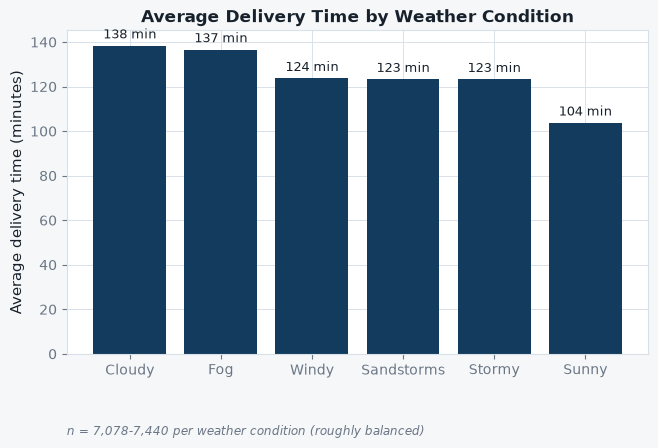

,n,mean,median,std,p90
Cloudy,"7,288.0000",138.2900,140.0000,55.4700,210.0000
Fog,"7,440.0000",136.5700,135.0000,57.2300,210.0000
Windy,"7,223.0000",123.6600,125.0000,48.5200,185.0000
Sandstorms,"7,245.0000",123.2400,125.0000,48.3100,185.0000
Stormy,"7,374.0000",123.2100,125.0000,47.8000,185.0000
Sunny,"7,078.0000",103.6600,100.0000,45.4400,160.0000


In [5]:
by_weather = pd.DataFrame(m1.describe_by_segment(df, "Weather")).T
by_weather = by_weather.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(by_weather.index, by_weather["mean"], color=NAVY)
annotate_bars(ax, bars, fmt="{:.0f} min", offset=2)
ax.set_title("Average Delivery Time by Weather Condition")
ax.set_ylabel("Average delivery time (minutes)")
sample_size_caption(ax, "n = 7,078-7,440 per weather condition (roughly balanced)")
plt.show()
by_weather


**Key observation:** Traffic shows a clear ordinal pattern (Low 101.35 min
→ Medium 126.84 → High 129.42 → Jam 147.76 min). Weather separates Cloudy/Fog
(~137-138 min, longest) from Sunny (103.66 min, shortest), with the other
four conditions in between. Notebook 05 confirms traffic's association is
statistically significant with a **large** effect size, and weather's is
significant but **small** — this chart shows the pattern; the formal test
establishes its strength.

**Limitation:** Descriptive group means only — "associated with," not
"caused by." See notebook 05 for the effect-size-qualified interpretation.


## 3. Delivery Time by Vehicle

**Analysis performed:** `describe_by_segment(df, "Vehicle")`.


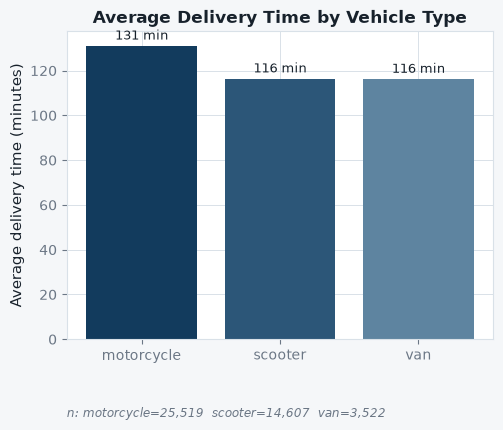

,n,mean,median,std,p90
motorcycle,"25,519.0000",131.0300,130.0000,53.6500,205.0000
scooter,"14,607.0000",116.3500,115.0000,48.1900,185.0000
van,"3,522.0000",116.1700,115.0000,47.8400,180.0000


In [6]:
by_vehicle = pd.DataFrame(m1.describe_by_segment(df, "Vehicle")).T.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(by_vehicle.index, by_vehicle["mean"], color=NEUTRAL_SEQUENCE[0:3])
annotate_bars(ax, bars, fmt="{:.0f} min", offset=1.5)
ax.set_title("Average Delivery Time by Vehicle Type")
ax.set_ylabel("Average delivery time (minutes)")
sample_size_caption(ax, "n: motorcycle=25,519  scooter=14,607  van=3,522")
plt.show()
by_vehicle


**Key observation:** motorcycle (131.03 min) averages slowest of the 3
present vehicle types; scooter (116.35 min) and van (116.17 min) are close
to each other and faster.

**Limitation:** `bicycle` cannot be compared — 0 rows exist in the cleaned
dataset for that vehicle type (documented absence, not a fabricated
comparison).


## 4. Weekday vs. Weekend

**Business question:** Is there an operationally meaningful difference in
delivery time between weekday and weekend orders?

**Analysis performed:** `weekend_vs_weekday()` from
`02_segment_comparisons.py`. Formal significance test is Test 5 in notebook
05.


In [7]:
wk = m2.weekend_vs_weekday(df)
wk_df = pd.DataFrame(wk).T
wk_df


,n,mean,median,std,p90
weekday,"31,627.0000",124.8960,125.0000,52.1200,195.0000
weekend,"12,021.0000",124.9631,125.0000,51.4400,195.0000


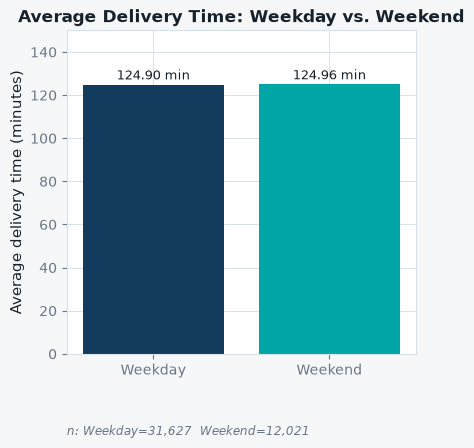

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 4.2))
bars = ax.bar(["Weekday", "Weekend"], [wk["weekday"]["mean"], wk["weekend"]["mean"]], color=[NAVY, TEAL])
annotate_bars(ax, bars, fmt="{:.2f} min", offset=1)
ax.set_ylim(0, 150)
ax.set_title("Average Delivery Time: Weekday vs. Weekend")
ax.set_ylabel("Average delivery time (minutes)")
sample_size_caption(ax, f"n: Weekday={wk['weekday']['n']:,}  Weekend={wk['weekend']['n']:,}")
plt.show()


**Key observation:** 124.90 min (weekday) vs. 124.96 min (weekend) — visibly
almost identical. Notebook 05's Test 5 confirms this is **not** a
statistically significant difference (p=0.9658), with a negligible effect
size.

**Limitation:** None beyond the general ~8-week dataset window.


## 5. Weekly Trend

**Business question:** Does average/P90 delivery time show a trend across
the observed weeks?

**Analysis performed:** `weekly_temporal_pattern()` from
`02_segment_comparisons.py` — partial weeks (fewer than 7 distinct calendar
days observed) are flagged, not silently treated as full weeks.


In [9]:
weekly = m2.weekly_temporal_pattern(df)
weekly_df = pd.DataFrame(weekly).T
weekly_df.index = weekly_df.index.astype(int)
weekly_df = weekly_df.sort_index()
weekly_df


,n,avg_delivery_time,p90_delivery_time,distinct_days_observed,partial_week_flag,avg_delta_vs_prior_week
6,2697,121.5400,190.0000,3,True,None
7,4273,129.1200,200.0000,5,True,7.5800
9,6153,124.0900,195.0000,6,True,-5.0300
10,7208,122.0800,190.0000,7,False,-2.0100
11,7072,128.2400,204.5000,7,False,6.1600
12,6110,124.3400,195.0000,6,True,-3.9000
13,7210,122.8700,190.0000,7,False,-1.4700
14,2925,128.7600,205.0000,3,True,5.8900


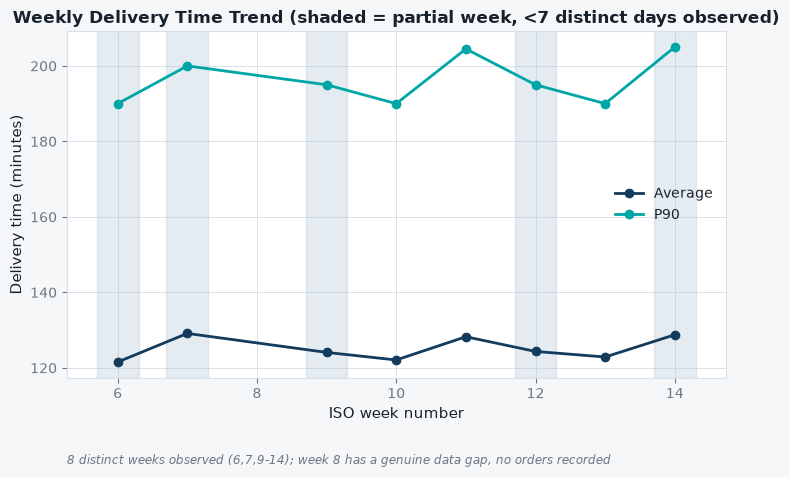

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(weekly_df.index, weekly_df["avg_delivery_time"], marker="o", color=NAVY, linewidth=2, label="Average")
ax.plot(weekly_df.index, weekly_df["p90_delivery_time"], marker="o", color=TEAL, linewidth=2, label="P90")
for wk_num, row in weekly_df.iterrows():
    if row["partial_week_flag"]:
        ax.axvspan(wk_num - 0.3, wk_num + 0.3, color=NEUTRAL_SEQUENCE[4], alpha=0.35)
ax.set_title("Weekly Delivery Time Trend (shaded = partial week, <7 distinct days observed)")
ax.set_xlabel("ISO week number")
ax.set_ylabel("Delivery time (minutes)")
ax.legend()
sample_size_caption(ax, "8 distinct weeks observed (6,7,9-14); week 8 has a genuine data gap, no orders recorded")
plt.show()


**Key observation:** Average delivery time ranges 121.54–129.12 min across
the 8 observed weeks — a roughly 6% swing, with no clear directional trend.
Weeks 6 and 14 are partial (3 distinct days each); weeks 9 and 12 are also
short (6 days).

**Limitation:** An 8-week window with two fully-partial weeks and a genuine
10-day gap (19–28 Feb, no orders recorded) does not support a strong trend
claim in either direction.

---

**Next:** [`03_sla_analysis.ipynb`](03_sla_analysis.ipynb) — SLA breach
performance by area and category, using the frozen SLA methodology.
